In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [3]:
# List available input files
for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Automatically find the Tesla CSV
csv_files = []
for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        if filename.endswith(".csv"):
            csv_files.append(os.path.join(dirname, filename))

DATA_PATH = csv_files[0]
print("Using dataset:", DATA_PATH)

df = pd.read_csv(DATA_PATH)

df["Date"] = pd.to_datetime(
    dict(year=df["Year"], month=df["Month"], day=1),
    errors="coerce"
)

df = df.sort_values(["Date", "Region", "Model"]).reset_index(drop=True)

print(df.shape)
df.head()

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv
Using dataset: /kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv
(2640, 13)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2015,1,Asia,Cybertruck,11325,11887,54449.08,60,339,575.88,Estimated (Region),6902,2015-01-01
1,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01
2,2015,1,Asia,Model S,9537,10093,68994.43,82,484,692.39,Official (Quarter),7281,2015-01-01
3,2015,1,Asia,Model X,7292,7298,107082.30,120,702,767.85,Estimated (Region),11748,2015-01-01
4,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01


In [4]:
TARGET = "Estimated_Deliveries"

# CO2_Saved_tons is excluded because it may be calculated from deliveries,
# so using it could cause target leakage.
categorical_features = ["Region", "Model", "Source_Type"]

numeric_features = [
    "Year",
    "Month",
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "Charging_Stations",
]

feature_columns = numeric_features + categorical_features

usable_df = df.dropna(subset=[TARGET]).copy()

X = usable_df[feature_columns]
y = usable_df[TARGET]

split_index = int(len(usable_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

test_meta = usable_df.iloc[split_index:][["Date", "Year", "Month", "Region", "Model"]]

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))

Train rows: 2112
Test rows: 528


In [5]:
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", onehot),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

model = RandomForestRegressor(
    n_estimators=120,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ]
)

In [6]:
tscv = TimeSeriesSplit(n_splits=3)

cv_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
)

print("CV RMSE scores:", -cv_scores)
print("Mean CV RMSE:", -cv_scores.mean())
print("CV RMSE std:", cv_scores.std())

CV RMSE scores: [1672.35013752 1291.17445315 1221.32165848]
Mean CV RMSE: 1394.9487497182708
CV RMSE std: 198.21453141757277


In [7]:
pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_test)
predictions = np.clip(predictions, a_min=0, a_max=None)

baseline_value = y_train.median()
baseline_predictions = np.full_like(y_test, baseline_value, dtype=float)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_rmse = rmse(y_test, baseline_predictions)

model_mae = mean_absolute_error(y_test, predictions)
model_rmse = rmse(y_test, predictions)
model_r2 = r2_score(y_test, predictions)

print("Evaluation Results")
print("------------------")
print(f"Baseline MAE:  {baseline_mae:.2f}")
print(f"Baseline RMSE: {baseline_rmse:.2f}")
print(f"Model MAE:     {model_mae:.2f}")
print(f"Model RMSE:    {model_rmse:.2f}")
print(f"Model R2:      {model_r2:.4f}")

Evaluation Results
------------------
Baseline MAE:  2941.97
Baseline RMSE: 3658.95
Model MAE:     669.90
Model RMSE:    936.85
Model R2:      0.9344


In [8]:
results = test_meta.copy()
results["actual_deliveries"] = y_test.values
results["predicted_deliveries"] = predictions.round().astype(int)
results["absolute_error"] = (
    results["actual_deliveries"] - results["predicted_deliveries"]
).abs()

results.to_csv("/kaggle/working/test_predictions.csv", index=False)

results.head()

,Date,Year,Month,Region,Model,actual_deliveries,predicted_deliveries,absolute_error
2112,2023-10-01,2023,10,Middle East,Model S,8179,8884,705
2113,2023-10-01,2023,10,Middle East,Model X,4490,4952,462
2114,2023-10-01,2023,10,Middle East,Model Y,14734,14231,503
2115,2023-10-01,2023,10,North America,Cybertruck,11110,10900,210
2116,2023-10-01,2023,10,North America,Model 3,11636,11908,272


In [9]:
preprocessor_fitted = pipeline.named_steps["preprocessor"]
model_fitted = pipeline.named_steps["model"]

onehot_fitted = preprocessor_fitted.named_transformers_["cat"].named_steps["onehot"]
encoded_cats = onehot_fitted.get_feature_names_out(categorical_features)

feature_names = np.concatenate([numeric_features, encoded_cats])

feature_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": model_fitted.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance.to_csv("/kaggle/working/feature_importance.csv", index=False)

feature_importance.head(10)

,feature,importance
0,Production_Units,0.797717
1,Avg_Price_USD,0.038436
2,Charging_Stations,0.036289
3,Range_km,0.031193
4,Month,0.022996
5,Year,0.017946
6,Battery_Capacity_kWh,0.010166
7,Source_Type_Official (Quarter),0.004645
8,Region_Asia,0.004220
9,Model_Model S,0.004110


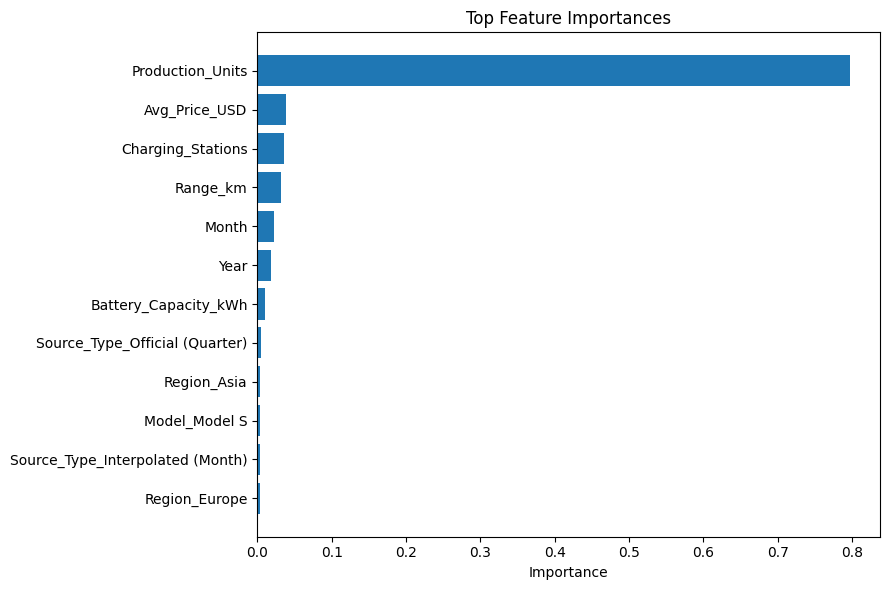

In [10]:
top_features = feature_importance.head(12).sort_values("importance")

plt.figure(figsize=(9, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("/kaggle/working/feature_importance.png", dpi=160)
plt.show()

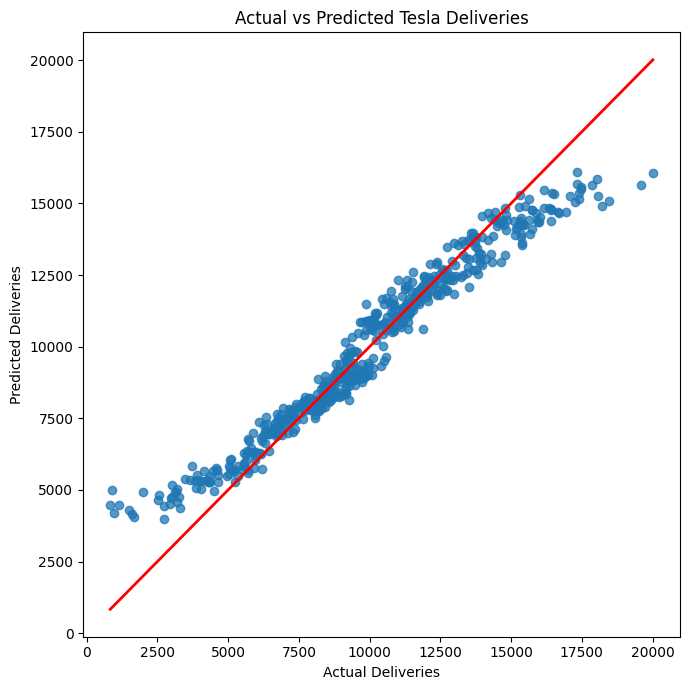

In [11]:
plt.figure(figsize=(7, 7))
plt.scatter(
    results["actual_deliveries"],
    results["predicted_deliveries"],
    alpha=0.75
)

low = min(results["actual_deliveries"].min(), results["predicted_deliveries"].min())
high = max(results["actual_deliveries"].max(), results["predicted_deliveries"].max())

plt.plot([low, high], [low, high], color="red", linewidth=2)
plt.title("Actual vs Predicted Tesla Deliveries")
plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")
plt.tight_layout()
plt.savefig("/kaggle/working/actual_vs_predicted.png", dpi=160)
plt.show()

In [12]:
metrics = {
    "rows": len(usable_df),
    "train_rows": len(X_train),
    "test_rows": len(X_test),
    "baseline_mae": baseline_mae,
    "baseline_rmse": baseline_rmse,
    "model_mae": model_mae,
    "model_rmse": model_rmse,
    "model_r2": model_r2,
    "cv_rmse_mean": -cv_scores.mean(),
    "cv_rmse_std": cv_scores.std(),
}

metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv("/kaggle/working/metrics.csv", index=False)

metrics_df

,rows,train_rows,test_rows,baseline_mae,baseline_rmse,model_mae,model_rmse,model_r2,cv_rmse_mean,cv_rmse_std
0,2640,2112,528,2941.971591,3658.951978,669.89882,936.846253,0.934413,1394.94875,198.214531


## Tesla Deliveries Prediction Model

This project builds a machine learning regression model to predict Tesla's estimated vehicle deliveries. The target variable is `Estimated_Deliveries`.

The model uses vehicle, market, pricing, production, and infrastructure-related features such as year, month, region, model, production units, average price, battery capacity, range, source type, and charging stations.

`CO2_Saved_tons` was excluded because it may be derived from deliveries, which could cause target leakage.

A Random Forest Regressor was used because it works well with nonlinear relationships and mixed feature types. Numeric features were imputed and scaled, while categorical features were imputed and one-hot encoded.

The data was split chronologically, using the first 80% for training and the last 20% for testing. TimeSeriesSplit cross-validation was also used to evaluate model stability.